# Read before Run

One of the provided files, **avGFP_full_sequences.csv**, contained severe duplications, resulting in only 456 unique sequences out of over 50,000 entries. Due to this redundancy, we opted to use **GFP data.xlsx** instead. Since the goal is to improve avGFP, we focus solely on the information related to avGFP and exclude its homologs from the analysis.

### Section 1 Extract Dataset for Training and Test

In [15]:
# Implemented by JYT on 19 June 2025 – Latest version
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
mutation_df = pd.read_excel('../data/GFP data.xlsx')
mutation_df = mutation_df[mutation_df['GFP type'] == 'avGFP']

In [28]:
avGFP = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
amacGFP = 'MSKGEELFTGIVPVLIELDGDVHGHKFSVRGEGEGDADYGKLEIKFICTTGKLPVPWPTLVTTLSYGILCFARYPEHMKMNDFFKSAMPEGYIQERTIFFQDDGKYKTRGEVKFEGDTLVNRIELKGMDFKEDGNILGHKLEYNFNSHNVYIMPDKANNGLKVNFKIRHNIEGGGVQLADHYQTNVPLGDGPVLIPINHYLSCQTAISKDRNETRDHMVFLEFFSACGHTHGMDELYK'
cgreGFP = 'MTALTEGAKLFEKEIPYITELEGDVEGMKFIIKGEGTGDATTGTIKAKYICTTGDLPVPWATILSSLSYGVFCFAKYPRHIADFFKSTQPDGYSQDRIISFDNDGQYDVKAKVTYENGTLYNRVTVKGTGFKSNGNILGMRVLYHSPPHAVYILPDRKNGGMKIEYNKAFDVMGGGHQMARHAQFNKPLGAWEEDYPLYHHLTVWTSFGKDPDDDETDHLTIVEVIKAVDLETYR'
ppluGFP = 'MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFSPYLLSHVMGYGFYHFGTYPSGYENPFLHAINNGGYTNTRIEKYEDGGVLHVSFSYRYEAGRVIGDFKVVGTGFPEDSVIFTDKIIRSNATVEHLHPMGDNVLVGSFARTFSLRDGGYYSFVVDSHMHFKSAIHPSILQNGGPMFAFRRVEELHSNTELGIVEYQHAFKTPIAFA'

wts = {
    'avGFP':avGFP,
    'amacGFP':amacGFP,
    'cgreGFP':cgreGFP,
    'ppluGFP':ppluGFP
}

In [30]:
Fullsequences = []
positions = set()
for mutant, gfp_type in zip(mutation_df['aaMutations'].tolist(), mutation_df['GFP type'].tolist()):
    wt = wts[gfp_type]
    if mutant == "WT":
        Fullsequences.append(wt)
        continue
    mutant = mutant.split(':')
    var = wt
    for mu in mutant:
        
        aa1, pos, aa2 = mu[0], int(mu[1:-1]), mu[-1]
        if aa1 == '*' or aa1 == '.':
            var = "*"
            break
        if pos not in positions:
            positions.add(pos)

        if var[pos] != aa1:
            var = "*"
            break
        var = var[:pos] + aa2 + var[pos+1:]
        assert len(var) == len(wt)
    Fullsequences.append(var)
mutation_df["FullSequence"] = Fullsequences
mutation_df.head()

,aaMutations,GFP type,Brightness,FullSequence
0,WT,avGFP,3.719212,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
1,A109D,avGFP,1.301030,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
2,A109D:N145D:I187V:M232T:L235P,avGFP,1.301031,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
3,A109D:Y142N:H147L:E221G,avGFP,1.301189,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
4,A109G,avGFP,3.708478,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...


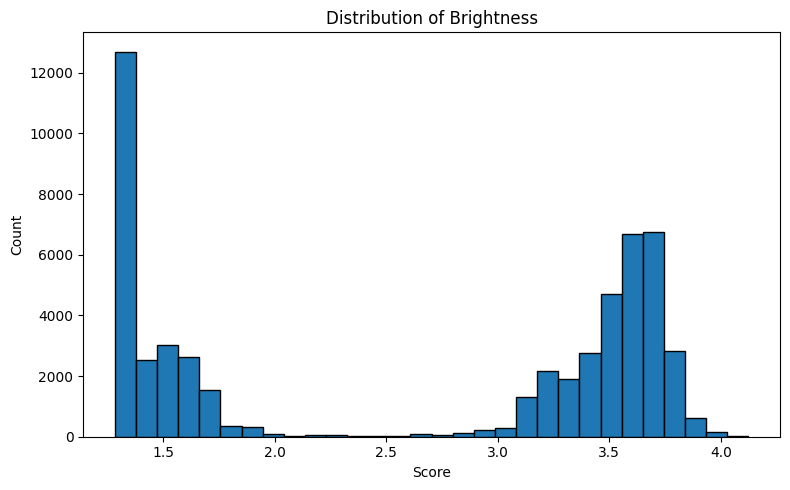

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(mutation_df['Brightness'], bins=30, edgecolor='black')  # 可调 bins 数量
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Brightness")
plt.tight_layout()
plt.show()

In [31]:
mutation_df.to_csv('../data/deduplicated_variants.csv', index=False)

### Section 2 spatial-distance-attn-mask

To enable our **spatial-distance attention mask**, run the section below and set the **residue_mask** attribute of the **ItPredConfig** class to True in the *model.py* file.

In [1]:
from Bio.PDB import PDBParser
import numpy as np
import seaborn as sns
def extract_ca_coords(pdb_path: str):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_path)

    ca_coords = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    atom = residue["CA"]
                    ca_coords.append(atom.coord)

    if not ca_coords:
        raise ValueError(f"No CA atoms found in {pdb_path}")

    ca_array = np.array(ca_coords, dtype=np.float32)  # (L, 3)
    return ca_array


ca_3d = extract_ca_coords('../data/4 kinds of GFP Protein structures/avGFP__2wur.pdb')

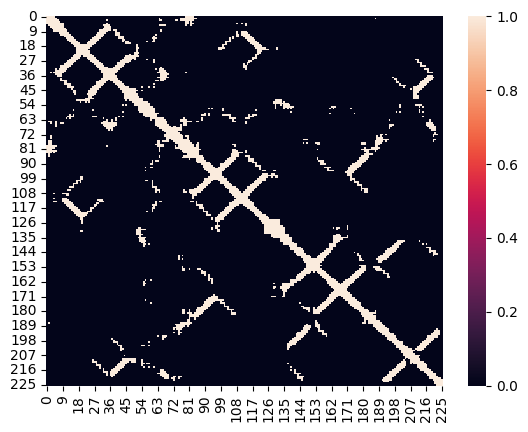

In [3]:
# In our implementation, two residues are considered to interact if the distance between them is less than 10 Å.
distances = np.zeros((len(ca_3d), len(ca_3d)))
for i in range(len(ca_3d)):
    for j in range(len(ca_3d)):
        dis = np.linalg.norm(ca_3d[i] - ca_3d[j])
        distances[i, j] = dis

spatial_distance_attn_mask = (distances < 10)

sns.heatmap(spatial_distance_attn_mask)
np.save('../data/spatial_distance_attn_mask.npy', spatial_distance_attn_mask)

### Section 3 Key Residue Determination

In [33]:
import pandas as pd

mutation_df = pd.read_csv('../data/deduplicated_variants.csv')
mutation_df_above_4 = mutation_df[mutation_df['Brightness'] > 4.]
mutation_df_above_4.reset_index(inplace=True, drop=True)
mutation_df_above_4.head()

,aaMutations,GFP type,Brightness,FullSequence
0,A86T:K157R:I170L,avGFP,4.030664,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
1,D75G:I127T,avGFP,4.005134,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
2,E110V:V175A:A226T,avGFP,4.030503,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
3,E141V:Q176L,avGFP,4.019220,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
4,E31G:E131A,avGFP,4.013150,MSKGEELFTGVVPILVELDGDVNGHKFSVSGGGEGDATYGKLTLKF...


In [34]:
mutation_df_above_4.to_csv('../data/deduplicated_variants_above_4.csv')

### Section 4 Split into fasta file with 100 variants each

If you plan to incorporate structural information in the downstream machine learning regression task, you’ll need to run the procedure below in advance. 

*Note:* The script uses the official ESM API (from the ESM GitHub repository) to fetch predicted PDB structures. Please be aware that this process can be slow, especially when handling a large number of sequences, due to rate-limiting constraints on their server.

In [40]:
import pandas as pd
import os

def write_fasta_batches(seqs: list[str], save_dir: str, start_id: int, batch_size: int = 100):

    os.makedirs(save_dir, exist_ok=True)
    print(len(seqs))
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i + batch_size]
        filename = os.path.join(save_dir, f"avGFP_var_from_{i}_{i+batch_size}.fasta")
        
        with open(filename, "w") as f:
            for j, seq in enumerate(batch):
                header = f">variant_{i + j + 1}"
                f.write(f"{header}\n{seq}\n")


df = pd.read_csv('../data/deduplicated_variants.csv')
write_fasta_batches(df['FullSequence'].tolist(), '../data/avGFP_var', 0)


54025


In [44]:
!python -u download_PDB.py -i 0

Now handling 0 protein
Now handling 1 protein
Now handling 2 protein
Now handling 3 protein
Now handling 4 protein
Now handling 5 protein
Now handling 6 protein
Now handling 7 protein
Now handling 8 protein
Now handling 9 protein
Now handling 10 protein
Now handling 11 protein
Now handling 12 protein
Now handling 13 protein
Now handling 14 protein
Now handling 15 protein
Now handling 16 protein
Now handling 17 protein
Now handling 18 protein
Now handling 19 protein
Now handling 20 protein
Now handling 21 protein
Now handling 22 protein
Now handling 23 protein
Now handling 24 protein
Now handling 25 protein
Now handling 26 protein
Now handling 27 protein
Now handling 28 protein
Now handling 29 protein
Now handling 30 protein
Now handling 31 protein
Error (try 1): 504 Server Error: Gateway Timeout for url: https://api.esmatlas.com/foldSequence/v1/pdb/
Now handling 32 protein
Now handling 33 protein
Now handling 34 protein
Now handling 35 protein
Now handling 36 protein
Now handling 37 pr

### Section 5 Select Results

In [7]:
import pandas as pd
import json
df = pd.read_csv('../data/Exclusion_List.csv')

res = []
with open("../Final_result.jsonl", "r") as f:
    for line in f:
        res.append(json.loads(line))
res

[{'Sequence': 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSEMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQRNGIKVNFKIRHNGEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK',
  'Residues': [86, 157, 170],
  'Predicted Brightness': 3.7193269192914507,
  'Predicted Energy': 4.594937582798091,
  'Dataset best': 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSTMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQRNGIKVNFKIRHNLEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK',
  'Dataset predicted Brightness': 3.688176455195782,
  'Dataset predicted Energy': 7.001195748384686,
  'Sum of Score': -0.8756106635066407},
 {'Sequence': 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPQHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGCDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKD

In [8]:
res = [r for r in res if r['Sequence'] not in df['sequences-not-submit'].tolist()]
print(len(res))
res = [r for r in res if r['Predicted Brightness'] > r['Dataset predicted Brightness']]
print(len(res))

54
36


In [13]:
res_sorted = sorted(res, key=lambda r: r['Predicted Brightness'], reverse=True)
for i, r in enumerate(res_sorted):
    print(i)
    print(r['Residues'])
    print(r['Sequence'])
    print(r['Predicted Brightness'])
    print(r['Dataset predicted Brightness'])
    print(r['Sum of Score'])

0
[120, 152, 170]
MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLV*RIELKGIDFKEDGNILGHKLEYNYNSHNVYIRADKQKNGIKVNFKIRHNAEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK
3.764517019353252
3.641189552464906
-5884.981291248876
1
[5, 75, 104]
MSKGEKLFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPNHMKQHDFFKSAMPEGYVQERTIFFKDDGWYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK
3.7513965846833943
3.750699311991676
-5.796563988979289
2
[4, 120]
MSKGWELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLV*RIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK
3.737268516727621
3.613417680727848
-5902.23595107851
3
[110, 175, 226]
MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVP

In [26]:
avGFP = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'

final_seqs = []
final_mutation_descrptions = []
for i in [0, 1, 3, 4, 5, 9]:
    final_seqs.append(res_sorted[i]['Sequence'])
    mutation = res_sorted[i]['Residues']
    # print(mutation)
    mutation = ':'.join([f'{avGFP[residue]}{residue+1}{res_sorted[i]["Sequence"][residue]}' for residue in mutation])
    final_mutation_descrptions.append(mutation)

final_df = pd.DataFrame(
    list(zip(final_mutation_descrptions, final_seqs)),
    columns=['Mutant', 'Sequence']
)
final_df.to_csv('../Final_result.csv')